In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav_history = pd.read_csv("../data/processed/nav_history_cleaned.csv")
scheme_performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

print(nav_history.shape)
print(scheme_performance.shape)

(46000, 3)
(40, 19)


In [22]:

nav_history["date"] = pd.to_datetime(nav_history["date"])

nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


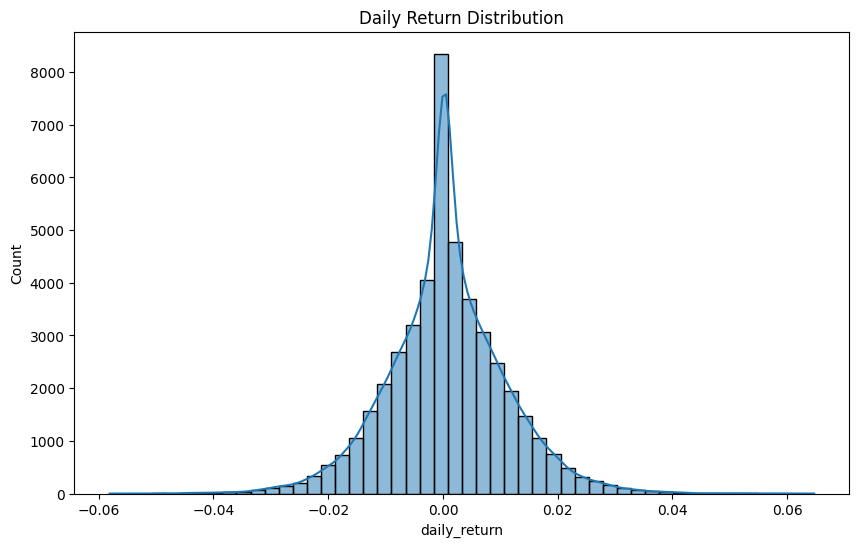

In [23]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav_history["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Daily Return Distribution")

plt.show()

In [24]:
nav_history.to_csv(
    "../data/processed/nav_returns.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [25]:
print(scheme_performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [26]:
scheme_performance.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade']

In [27]:
cagr_table = scheme_performance[
    [
        "amfi_code",
        "scheme_name",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct"
    ]
]

cagr_table.head()

,amfi_code,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,119552,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,119598,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,119599,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


In [28]:
cagr_table.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

print("CAGR Table Saved")

CAGR Table Saved


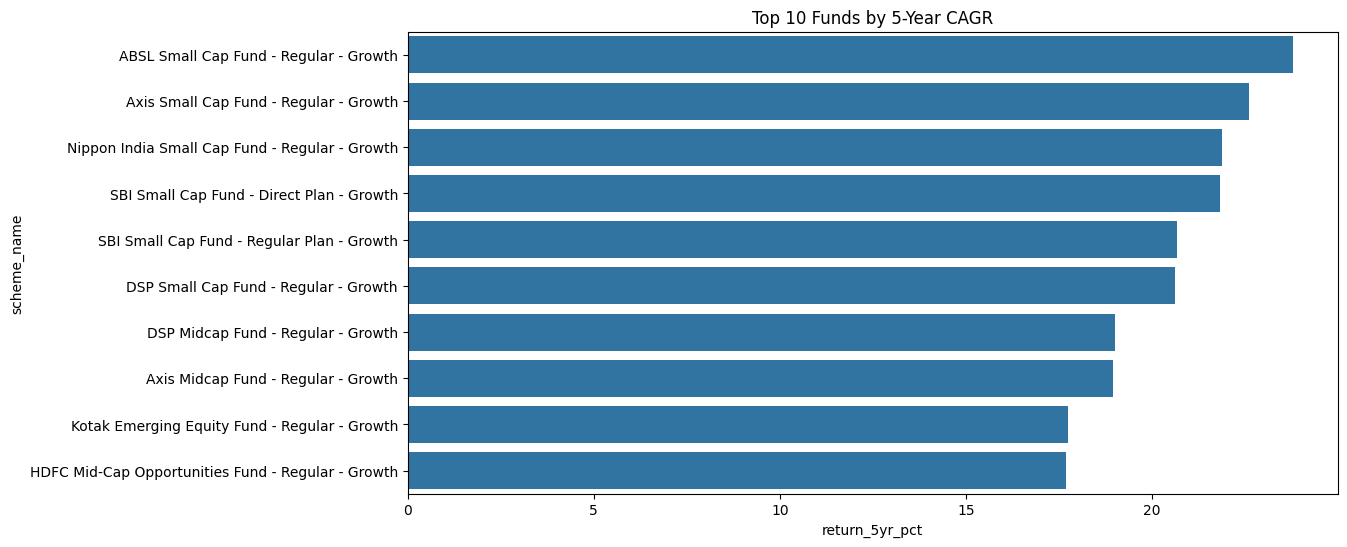

In [29]:
top_cagr = scheme_performance.sort_values(
    by="return_5yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_cagr,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 5-Year CAGR")

plt.show()

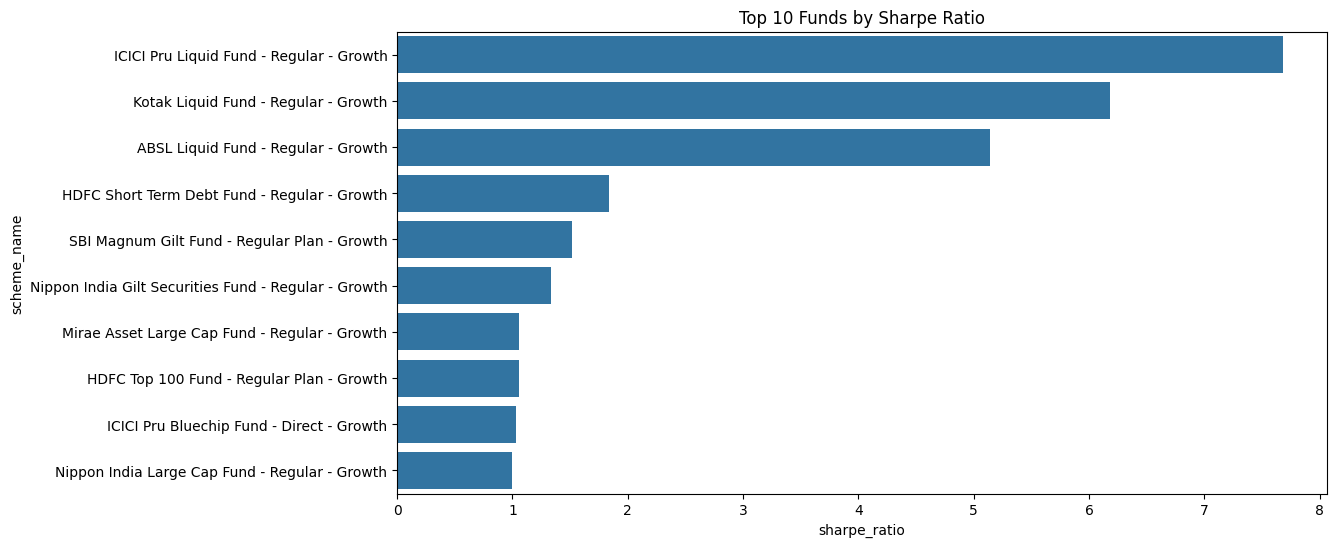

In [30]:
top_sharpe = scheme_performance.sort_values(
    by="sharpe_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.show()

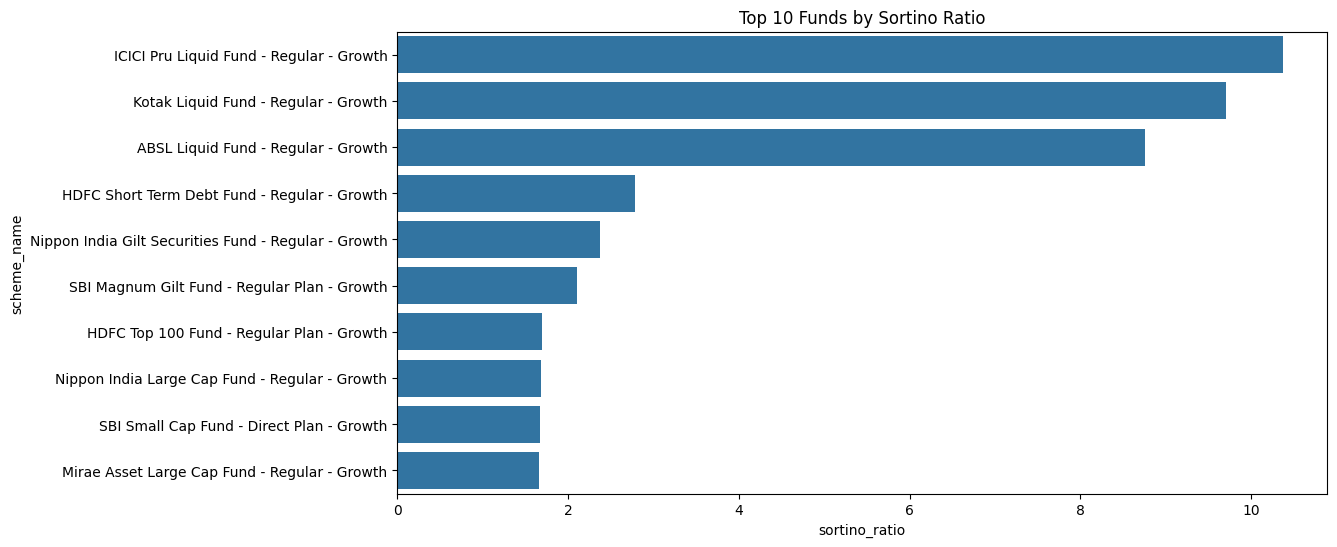

In [31]:
top_sortino = scheme_performance.sort_values(
    by="sortino_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sortino,
    x="sortino_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.show()

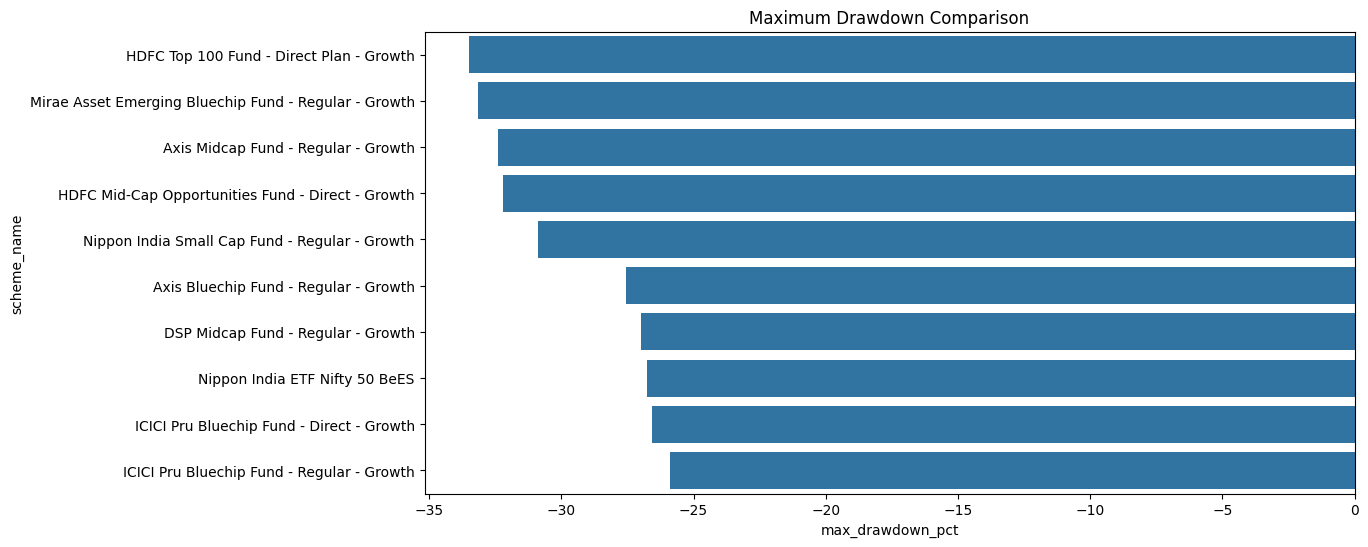

In [32]:
worst_dd = scheme_performance.sort_values(
    by="max_drawdown_pct"
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=worst_dd,
    x="max_drawdown_pct",
    y="scheme_name"
)

plt.title("Maximum Drawdown Comparison")

plt.show()

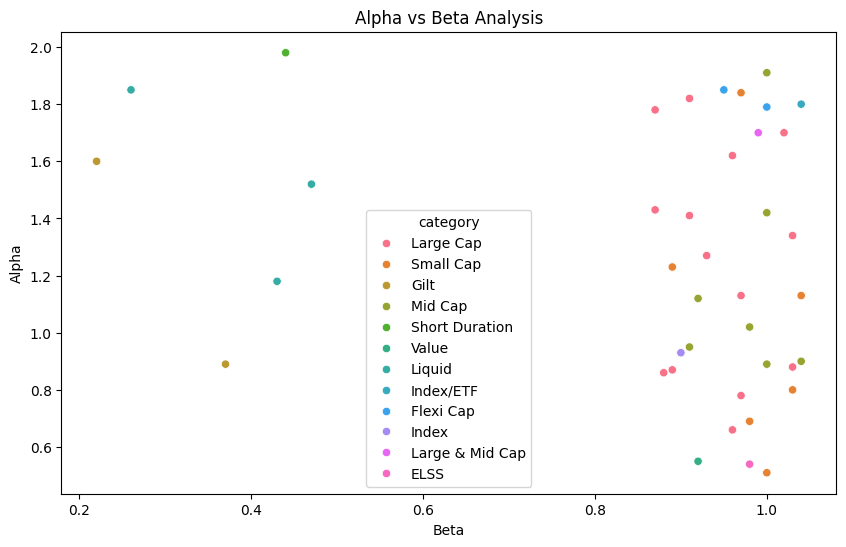

In [33]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=scheme_performance,
    x="beta",
    y="alpha",
    hue="category"
)

plt.title("Alpha vs Beta Analysis")

plt.xlabel("Beta")
plt.ylabel("Alpha")

plt.show()

In [34]:
scorecard = scheme_performance.copy()

scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(pct=True) * 100
scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(pct=True) * 100
scorecard["alpha_rank"] = scorecard["alpha"].rank(pct=True) * 100

scorecard["expense_rank"] = (
    100 - scorecard["expense_ratio_pct"].rank(pct=True) * 100
)

scorecard["drawdown_rank"] = (
    100 - scorecard["max_drawdown_pct"].rank(pct=True) * 100
)

scorecard["fund_score"] = (
    0.30 * scorecard["return_rank"] +
    0.25 * scorecard["sharpe_rank"] +
    0.20 * scorecard["alpha_rank"] +
    0.15 * scorecard["expense_rank"] +
    0.10 * scorecard["drawdown_rank"]
)

scorecard[
    ["scheme_name","fund_score"]
].sort_values(
    by="fund_score",
    ascending=False
).head(10)

,scheme_name,fund_score
3,SBI Small Cap Fund - Direct Plan - Growth,72.1250
22,Kotak Flexicap Fund - Regular - Growth,70.8750
21,Kotak Emerging Equity Fund - Regular - Growth,69.8750
29,ABSL Small Cap Fund - Regular - Growth,67.6250
2,SBI Small Cap Fund - Regular Plan - Growth,63.7500
34,Mirae Asset Large Cap Fund - Regular - Growth,63.3125
9,HDFC Short Term Debt Fund - Regular - Growth,62.3750
14,ICICI Pru Liquid Fund - Regular - Growth,61.1250
12,ICICI Pru Midcap Fund - Regular - Growth,60.3750
11,ICICI Pru Bluechip Fund - Direct - Growth,59.0000


In [35]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved")

Fund Scorecard Saved


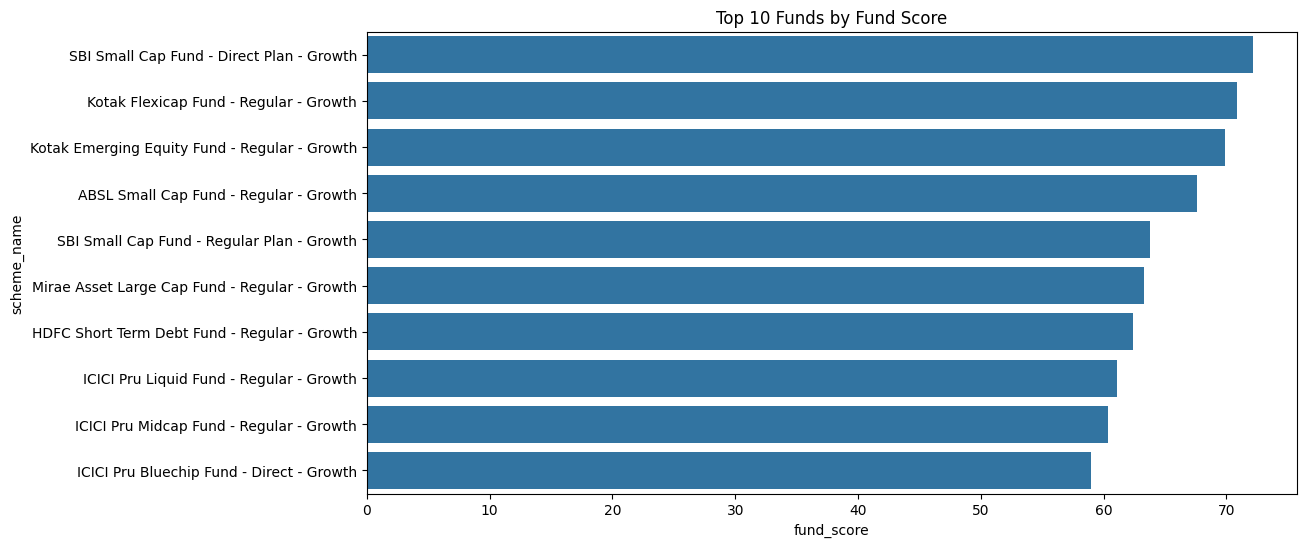

In [36]:
top_score = scorecard.sort_values(
    by="fund_score",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_score,
    x="fund_score",
    y="scheme_name"
)

plt.title("Top 10 Funds by Fund Score")

plt.show()

In [37]:
alpha_beta = scheme_performance[
    [
        "amfi_code",
        "scheme_name",
        "alpha",
        "beta"
    ]
]

alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("Alpha Beta CSV Saved")

Alpha Beta CSV Saved


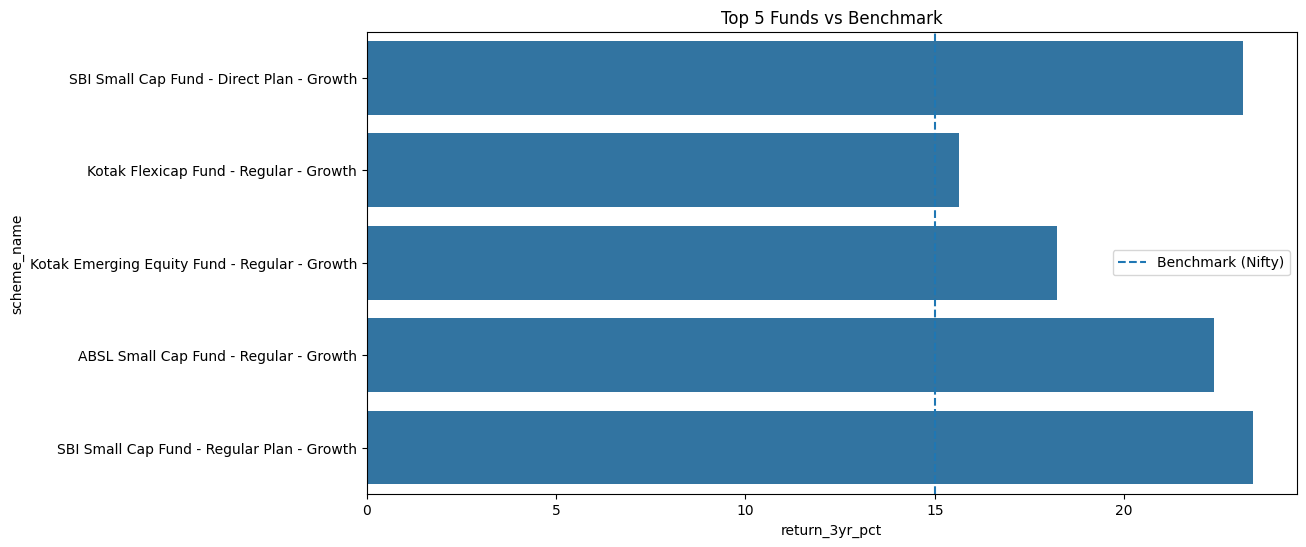

In [38]:
top5 = scorecard.sort_values(
    by="fund_score",
    ascending=False
).head(5)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top5,
    x="return_3yr_pct",
    y="scheme_name"
)

plt.axvline(
    x=15,
    linestyle="--",
    label="Benchmark (Nifty)"
)

plt.title("Top 5 Funds vs Benchmark")

plt.legend()

plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()

# Day 4 Findings

## Daily Returns
- Daily returns showed a normal distribution with a few extreme observations.

## CAGR Analysis
- Several funds delivered strong 3-year and 5-year CAGR performance.

## Sharpe and Sortino Ratios
- Top-ranked funds achieved superior risk-adjusted returns.

## Maximum Drawdown
- Some funds experienced significantly lower drawdowns, indicating better downside protection.

## Alpha and Beta
- Positive alpha funds outperformed benchmarks on a risk-adjusted basis.
- Beta values varied across funds, showing different market sensitivities.

## Fund Scorecard
- Composite fund scores helped identify the strongest overall performers using return, risk, alpha, expense ratio, and drawdown metrics.